# Modularidad

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

SEED = 863

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [12]:
# cargar la red real
from typing import List, Tuple

V: List[str] = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "GOOG", "AVGO", "META", "TSLA", "BRK.B",
    "JPM", "V", "MA", "WMT", "COST", "ORCL", "LLY", "XOM", "JNJ", "PLTR",
    "BAC", "ABBV", "MU", "HD", "NFLX", "AMD", "PG", "GE", "CVX", "UNH"
]

E: List[Tuple[str, str]] = [
    # semiconductores / hardware / computo
    ("MU", "NVDA"),
    ("AVGO", "AAPL"),
    ("NVDA", "MSFT"), ("NVDA", "AMZN"), ("NVDA", "GOOG"), ("NVDA", "GOOGL"),
    ("NVDA", "ORCL"), ("NVDA", "META"), ("NVDA", "TSLA"),
    ("AMD", "AMZN"), ("AMD", "MSFT"), ("AMD", "ORCL"), ("AMD", "TSLA"),

    # nube / servicios / datos
    ("AMZN", "NFLX"),
    ("AMZN", "XOM"), ("AMZN", "JNJ"), ("AMZN", "ABBV"),
    ("AMZN", "PLTR"),
    ("MSFT", "CVX"), ("MSFT", "GE"), ("MSFT", "UNH"),
    ("MSFT", "PLTR"),
    ("GOOGL", "PLTR"),
    ("ORCL", "PLTR"),

    # pagos / retail / consumo
    ("AAPL", "WMT"), ("AAPL", "COST"),
    ("PG", "WMT"),
    ("BRK.B", "WMT"),
    ("V", "COST"), ("V", "HD"), ("V", "BAC"),
    ("MA", "HD"), ("MA", "WMT"), ("MA", "AAPL"), ("MA", "BAC"),
    ("JPM", "AAPL"),

    # salud
    ("LLY", "AMZN"),
]

G_full = nx.Graph()
G_full.add_nodes_from(V)
G_full.add_edges_from(E)

# usar la componente principal
components = sorted(nx.connected_components(G_full), key=len, reverse=True)
G_real = G_full.subgraph(components[0]).copy()

# Guardar la red en un .gexf
nx.write_gexf(G_real, "data/sp500_main_component.gexf")


## 1. Actividad

En este notebook trabajo con la **componente principal** de la minired del S&P 500. La red manual completa tiene 2 componentes, pero la comunidad principal de 19 nodos es la parte donde realmente se puede estudiar modularidad y compararla de manera estable con el método espectral.


In [3]:
from networkx.algorithms.community import greedy_modularity_communities, louvain_communities


def get_display_labels(G):
    raw = nx.get_node_attributes(G, "label")
    return {node: raw.get(node, str(node)) for node in G.nodes()}


def communities_to_lookup(communities):
    lookup = {}
    for idx, community in enumerate(communities):
        for node in community:
            lookup[node] = idx
    return lookup


def sort_nodes_in_group(G, group, labels):
    return sorted(group, key=lambda node: (-G.degree(node), labels[node]))


def partition_summary(G, communities, labels):
    bet = nx.betweenness_centrality(G)
    rows = []
    for idx, community in enumerate(sorted(communities, key=len, reverse=True)):
        sub = G.subgraph(community)
        ranked_degree = sort_nodes_in_group(G, community, labels)
        ranked_bet = sorted(
            community,
            key=lambda node: (-bet[node], labels[node]),
        )
        rows.append(
            {
                "comunidad": idx,
                "tamano": len(community),
                "aristas_internas": sub.number_of_edges(),
                "densidad_interna": round(nx.density(sub), 4),
                "lideres_por_grado": ", ".join(labels[node] for node in ranked_degree[:6]),
                "lideres_por_intermediacion": ", ".join(labels[node] for node in ranked_bet[:4]),
                "miembros": ", ".join(labels[node] for node in ranked_degree),
            }
        )
    return pd.DataFrame(rows)


def bridge_edges_table(G, communities, labels, top_n=12):
    lookup = communities_to_lookup(communities)
    rows = []
    for u, v, data in G.edges(data=True):
        cu = lookup[u]
        cv = lookup[v]
        if cu == cv:
            continue
        rows.append(
            {
                "peso": data.get("weight", 1.0),
                "origen": labels[u],
                "comunidad_origen": cu,
                "destino": labels[v],
                "comunidad_destino": cv,
            }
        )
    if not rows:
        return pd.DataFrame(columns=["peso", "origen", "comunidad_origen", "destino", "comunidad_destino"])
    return pd.DataFrame(rows).sort_values(
        ["peso", "origen", "destino"],
        ascending=[False, True, True],
    ).head(top_n)


def draw_partition(ax, G, communities, labels, title, pos=None):
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
    lookup = communities_to_lookup(communities)
    node_colors = np.array([lookup[node] for node in G.nodes()])
    node_sizes = np.array([220 + 18 * G.degree(node) for node in G.nodes()])
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        alpha=0.25,
        width=1.0,
        edge_color="#94a3b8",
    )
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        cmap="nipy_spectral",
        linewidths=0.6,
        edgecolors="white",
    )
    font_size = 9 if G.number_of_nodes() <= 25 else 7
    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, font_size=font_size)
    ax.set_title(title)
    ax.axis("off")
    return pos


def full_modularity_matrix(G, nodelist=None):
    if nodelist is None:
        nodelist = list(G.nodes())
    m = G.number_of_edges()
    degrees = dict(G.degree())
    B = np.zeros((len(nodelist), len(nodelist)), dtype=float)
    for i, u in enumerate(nodelist):
        for j, v in enumerate(nodelist):
            adjacency = 1.0 if G.has_edge(u, v) else 0.0
            B[i, j] = adjacency - degrees[u] * degrees[v] / (2 * m)
    return B


def modularity_spectrum(G, labels):
    nodelist = list(G.nodes())
    B = full_modularity_matrix(G, nodelist=nodelist)
    eigvals, eigvecs = np.linalg.eigh(B)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    matrix_df = pd.DataFrame(
        B,
        index=[labels[node] for node in nodelist],
        columns=[labels[node] for node in nodelist],
    )
    eigen_df = pd.DataFrame(
        {
            "indice": np.arange(1, len(eigvals) + 1),
            "eigenvalor": eigvals,
        }
    )
    leading_df = pd.DataFrame(
        {
            "nodo": [labels[node] for node in nodelist],
            "componente_eigenvector_principal": eigvecs[:, 0],
            "signo": np.where(eigvecs[:, 0] >= 0, "+", "-"),
        }
    ).sort_values("componente_eigenvector_principal")
    return matrix_df, eigen_df, leading_df


def generalized_modularity_matrix(G, community):
    nodelist = list(community)
    B = full_modularity_matrix(G, nodelist=nodelist)
    row_sums = B.sum(axis=1)
    Bg = B.copy()
    diag = np.arange(len(nodelist))
    Bg[diag, diag] -= row_sums
    return Bg, nodelist


def leading_split_generalized(G, community, labels):
    Bg, nodelist = generalized_modularity_matrix(G, community)
    eigvals, eigvecs = np.linalg.eigh(Bg)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    leading_eval = float(eigvals[0])
    leading_vec = eigvecs[:, 0]
    signs = np.where(leading_vec >= 0, 1, -1)
    if np.all(signs == 1) or np.all(signs == -1):
        order_vec = np.argsort(leading_vec)
        half = len(nodelist) // 2
        signs = np.ones(len(nodelist), dtype=int)
        signs[order_vec[:half]] = -1
    group_pos = {nodelist[i] for i, sign in enumerate(signs) if sign > 0}
    group_neg = set(nodelist) - group_pos
    delta_q = float((signs @ Bg @ signs) / (4 * G.number_of_edges()))
    vector_df = pd.DataFrame(
        {
            "nodo": [labels[node] for node in nodelist],
            "componente": leading_vec,
            "signo": np.where(signs > 0, "+", "-"),
        }
    ).sort_values("componente")
    return {
        "grupo_positivo": group_pos,
        "grupo_negativo": group_neg,
        "leading_eigenvalue": leading_eval,
        "delta_q": delta_q,
        "eigenvalues": eigvals,
        "leading_vector_df": vector_df,
    }


def recursive_spectral_partition(G, target_count, labels):
    partition = [set(G.nodes())]
    trace_rows = []
    first_split = None
    while len(partition) < target_count:
        candidates = []
        for idx, community in enumerate(partition):
            if len(community) < 2:
                continue
            split = leading_split_generalized(G, community, labels)
            candidate_partition = (
                partition[:idx]
                + [split["grupo_positivo"], split["grupo_negativo"]]
                + partition[idx + 1 :]
            )
            candidates.append(
                {
                    "idx": idx,
                    "split": split,
                    "candidate_partition": candidate_partition,
                    "candidate_modularity": nx.algorithms.community.modularity(G, candidate_partition),
                }
            )
        best = max(
            candidates,
            key=lambda item: (
                item["split"]["delta_q"],
                item["split"]["leading_eigenvalue"],
            ),
        )
        split = best["split"]
        if first_split is None:
            first_split = split
        trace_rows.append(
            {
                "paso": len(trace_rows) + 1,
                "grupo_bisecado": best["idx"],
                "tamano_original": len(partition[best["idx"]]),
                "tamano_grupo_positivo": len(split["grupo_positivo"]),
                "tamano_grupo_negativo": len(split["grupo_negativo"]),
                "leading_eigenvalue": split["leading_eigenvalue"],
                "delta_q": split["delta_q"],
                "modularidad_acumulada": best["candidate_modularity"],
            }
        )
        partition = best["candidate_partition"]
    partition = sorted(partition, key=len, reverse=True)
    trace_df = pd.DataFrame(trace_rows)
    return partition, trace_df, first_split


def comparison_table(G, greedy_partition, spectral_partition):
    rows = [
        {
            "metodo": "greedy_modularity_communities",
            "comunidades": len(greedy_partition),
            "modularidad": nx.algorithms.community.modularity(G, greedy_partition),
        },
        {
            "metodo": "biseccion espectral",
            "comunidades": len(spectral_partition),
            "modularidad": nx.algorithms.community.modularity(G, spectral_partition),
        },
    ]
    try:
        louvain_partition = sorted(list(louvain_communities(G, seed=SEED)), key=len, reverse=True)
        rows.append(
            {
                "metodo": "louvain_communities",
                "comunidades": len(louvain_partition),
                "modularidad": nx.algorithms.community.modularity(G, louvain_partition),
            }
        )
    except Exception:
        pass
    return pd.DataFrame(rows).sort_values("modularidad", ascending=False).reset_index(drop=True)


def plot_modularity_heatmap(ax, matrix_df, title):
    values = matrix_df.to_numpy()
    vmax = np.abs(values).max()
    image = ax.imshow(values, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    step = max(1, len(matrix_df) // 12)
    ticks = np.arange(0, len(matrix_df), step)
    ax.set_xticks(ticks)
    ax.set_xticklabels(matrix_df.columns[::step], rotation=90, fontsize=8)
    ax.set_yticks(ticks)
    ax.set_yticklabels(matrix_df.index[::step], fontsize=8)
    ax.set_title(title)
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)


In [4]:
labels = get_display_labels(G_real)
pos_sp = nx.kamada_kawai_layout(G_real)

resumen_red = pd.DataFrame(
    [
        {
            "nodos": G_real.number_of_nodes(),
            "aristas": G_real.number_of_edges(),
            "densidad": nx.density(G_real),
            "grado_medio": np.mean([grado for _, grado in G_real.degree()]),
            "es_conexa": nx.is_connected(G_real),
        }
    ]
).round(4)

display(resumen_red)


,nodos,aristas,densidad,grado_medio,es_conexa
0,19,24,0.1404,2.5263,True


## 2. Comunidades

En esta minired aparecen **5 comunidades** y la modularidad es cercana a **0.372**, grande.

In [5]:
comunidades_greedy = sorted(list(greedy_modularity_communities(G_real)), key=len, reverse=True)
modularidad_greedy = nx.algorithms.community.modularity(G_real, comunidades_greedy)
resumen_greedy = partition_summary(G_real, comunidades_greedy, labels)
aristas_puente_greedy = bridge_edges_table(G_real, comunidades_greedy, labels, top_n=12)

print(f"Comunidades detectadas: {len(comunidades_greedy)}")
print(f"Modularidad greedy: {modularidad_greedy:.4f}")
display(resumen_greedy)
display(aristas_puente_greedy)


Comunidades detectadas: 5
Modularidad greedy: 0.3715


,comunidad,tamano,aristas_internas,densidad_interna,lideres_por_grado,lideres_por_intermediacion,miembros
0,0,6,5,0.3333,"AMZN, ABBV, JNJ, LLY, NFLX, XOM","AMZN, ABBV, JNJ, LLY","AMZN, ABBV, JNJ, LLY, NFLX, XOM"
1,1,4,3,0.5000,"NVDA, GOOG, META, MU","NVDA, GOOG, META, MU","NVDA, GOOG, META, MU"
2,2,4,3,0.5000,"MSFT, CVX, GE, UNH","MSFT, CVX, GE, UNH","MSFT, CVX, GE, UNH"
3,3,3,2,0.6667,"PLTR, ORCL, GOOGL","PLTR, ORCL, GOOGL","PLTR, ORCL, GOOGL"
4,4,2,1,1.0000,"AMD, TSLA","AMD, TSLA","AMD, TSLA"


,peso,origen,comunidad_origen,destino,comunidad_destino
7,1.0,AMZN,0,AMD,4
8,1.0,AMZN,0,PLTR,3
1,1.0,MSFT,2,AMD,4
0,1.0,MSFT,2,NVDA,1
2,1.0,MSFT,2,PLTR,3
3,1.0,NVDA,1,AMZN,0
4,1.0,NVDA,1,GOOGL,3
5,1.0,NVDA,1,ORCL,3
6,1.0,NVDA,1,TSLA,4
9,1.0,ORCL,3,AMD,4


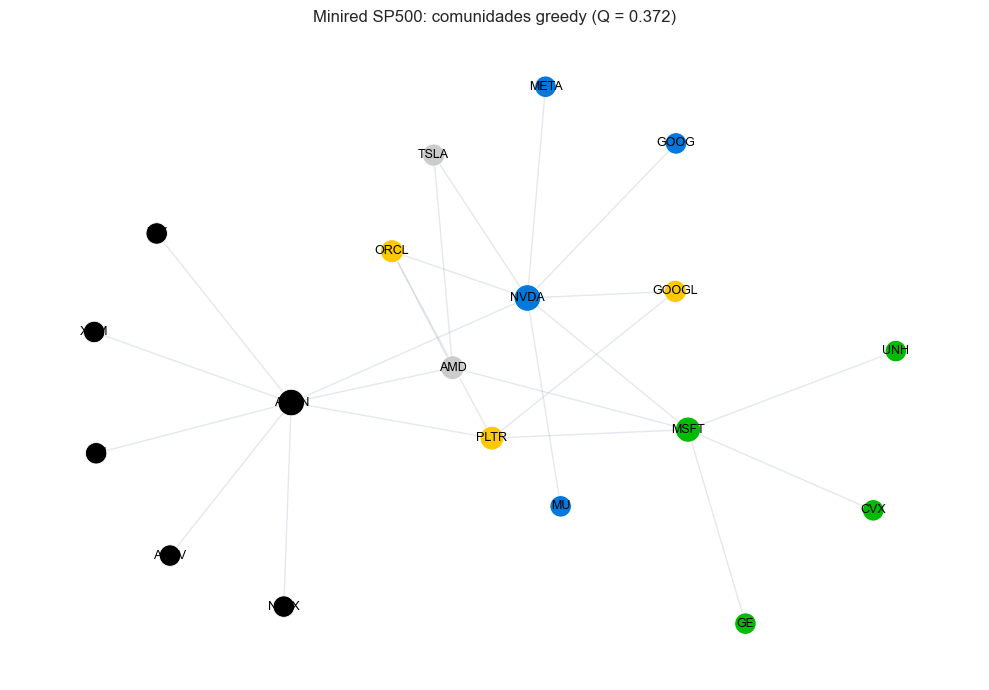

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
draw_partition(
    ax,
    G_real,
    comunidades_greedy,
    labels,
    title=f"Minired SP500: comunidades greedy (Q = {modularidad_greedy:.3f})",
    pos=pos_sp,
)
plt.tight_layout()
plt.show()


**¿Qué tipo de comunidades se detectan?**

Las comunidades se agrupan por patrones de dependencia dentro de la red proveedor-comprador.

- `AMZN`, `ABBV`, `JNJ`, `LLY`, `NFLX` y `XOM` forman un bloque porque casi toda su cohesión pasa por `AMZN`.
- `NVDA`, `GOOG`, `META` y `MU` quedan juntos porque se pegan al núcleo de cómputo y semiconductores donde esta `NVDA`.
- `MSFT`, `CVX`, `GE` y `UNH` forman otro bloque de dependencia alrededor de `MSFT`.
- `PLTR`, `ORCL` y `GOOGL` quedan como triada porque comparten una posición de analítica/datos conectada tanto al frente de IA como al frente corporativo.
- `AMD` y `TSLA` quedan como pareja muy cerrada, lo cual tiene sentido porque `TSLA` está conectada justo con `NVDA` y `AMD`, y aquí `AMD` aparece como una vía alternativa al bloque dominante de `NVDA`.

**Factores importantes para que los nodos queden en esas comunidades**

- Compartir un mismo hub dominante, como `AMZN`, `MSFT` o `NVDA`.
- Tener muy pocos vecinos externos, lo cual hace que el grupo sea fácil de aislar.
- Formar triadas o pares especialmente cerrados, como `PLTR-ORCL-GOOGL` o `AMD-TSLA`.
- Estar en posiciones de frontera. En esta red `AMD`, `PLTR` y `ORCL` son clave porque pueden engancharse con varios bloques, y por eso distintos métodos no siempre los colocan en el mismo lugar.


## 2.1 Partición de Gephi con `Modularity Class`

![03 sp.png](<attachment:03 sp.png>)

**Interpretación de la partición en Gephi**

En Gephi aparecen **4 comunidades** con modularidad cercana a **0.369**. La partición tinene una diferencia en los grupos: `NVDA`, `GOOG`, `GOOGL`, `MU`, `META`, `PLTR` y `ORCL`. Gephi fusiona en una sola comunidad lo que en Python quedó separado en dos bloques, el núcleo `NVDA-GOOG-META-MU` y la triada `PLTR-ORCL-GOOGL`. 

Esto ocurre porque no está usando el mismo algoritmo que el notebook. En Python usamos `greedy_modularity_communities`, mientras que `Modularity Class` en Gephi usa una heurística tipo *Louvain* para optimizar modularidad. La partición de Python tiene modularidad de 0.3715, mientras que la de Gephi tiene 0.369.

La separación entre `NVDA-GOOG-META-MU` y `PLTR-ORCL-GOOGL` es real, pero débil. Son grupos pequeños, están muy cerca entre sí y los unen nodos como `NVDA`, `ORCL`, `GOOGL` y `PLTR`. Dividirlos en dos comunidades mejora el valor total, pero solo un poco.
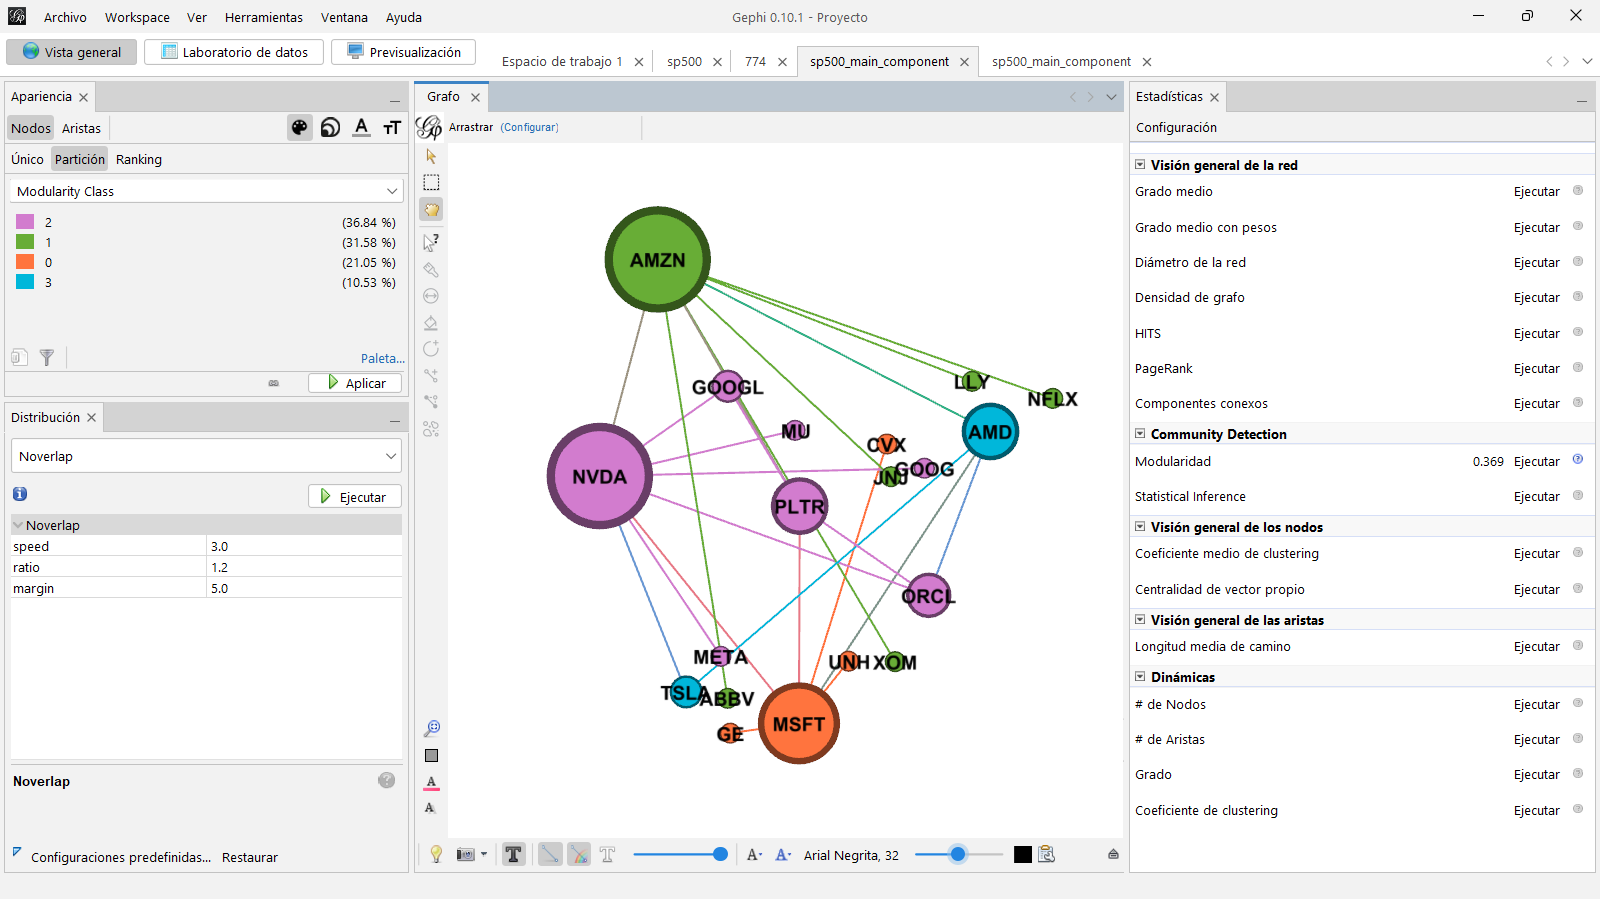

## 3. Matriz de modularidad, eigenvalores y eigenvectores

Ahora uso la matriz de modularidad $B$ y el algoritmo de **bisección espectral recursiva**. La idea es partir con toda la red en un solo grupo, tomar el eigenvector principal para bisecar, y repetir el proceso hasta tener la misma cantidad de comunidades detectadas con `greedy_modularity_communities`.


In [7]:
B_df_sp, eigen_df_sp, leading_df_sp = modularity_spectrum(G_real, labels)
comunidades_spectral, trace_sp, first_split_sp = recursive_spectral_partition(
    G_real,
    target_count=len(comunidades_greedy),
    labels=labels,
)
modularidad_spectral = nx.algorithms.community.modularity(G_real, comunidades_spectral)
resumen_spectral = partition_summary(G_real, comunidades_spectral, labels)
comparacion_sp = comparison_table(G_real, comunidades_greedy, comunidades_spectral)

display(comparacion_sp.round(4))
display(eigen_df_sp.head(10).round(4))
display(leading_df_sp.round(4))
display(trace_sp.round(4))
display(resumen_spectral)
display(B_df_sp.round(2))


,metodo,comunidades,modularidad
0,greedy_modularity_communities,5,0.3715
1,louvain_communities,5,0.3715
2,biseccion espectral,5,0.3490


,indice,eigenvalor
0,1,2.0534
1,2,1.6203
2,3,1.0000
3,4,0.9871
4,5,0.0000
5,6,0.0000
6,7,0.0000
7,8,0.0000
8,9,0.0000
9,10,0.0000


,nodo,componente_eigenvector_principal,signo
0,MSFT,-0.3776,-
1,NVDA,-0.2210,-
18,UNH,-0.1807,-
17,CVX,-0.1807,-
16,GE,-0.1807,-
7,ORCL,-0.1231,-
6,TSLA,-0.1138,-
3,GOOGL,-0.1138,-
13,MU,-0.1044,-
4,GOOG,-0.1044,-


,paso,grupo_bisecado,tamano_original,tamano_grupo_positivo,tamano_grupo_negativo,leading_eigenvalue,delta_q,modularidad_acumulada
0,1,0,19,6,13,2.0534,0.2700,0.2700
1,2,1,13,7,6,0.9635,0.0937,0.3637
2,3,1,7,3,4,0.1996,0.0026,0.3663
3,4,1,3,2,1,0.0000,-0.0174,0.3490


,comunidad,tamano,aristas_internas,densidad_interna,lideres_por_grado,lideres_por_intermediacion,miembros
0,0,6,5,0.3333,"AMZN, ABBV, JNJ, LLY, NFLX, XOM","AMZN, ABBV, JNJ, LLY","AMZN, ABBV, JNJ, LLY, NFLX, XOM"
1,1,6,5,0.3333,"NVDA, GOOGL, TSLA, GOOG, META, MU","NVDA, GOOGL, TSLA, GOOG","NVDA, GOOGL, TSLA, GOOG, META, MU"
2,2,4,3,0.5000,"MSFT, CVX, GE, UNH","MSFT, CVX, GE, UNH","MSFT, CVX, GE, UNH"
3,3,2,1,1.0000,"PLTR, ORCL","PLTR, ORCL","PLTR, ORCL"
4,4,1,0,0.0000,AMD,AMD,AMD


,MSFT,NVDA,AMZN,GOOGL,GOOG,META,TSLA,ORCL,LLY,XOM,JNJ,PLTR,ABBV,MU,NFLX,AMD,GE,CVX,UNH
MSFT,-0.75,0.00,-1.00,-0.25,-0.12,-0.12,-0.25,-0.38,-0.12,-0.12,-0.12,0.50,-0.12,-0.12,-0.12,0.50,0.88,0.88,0.88
NVDA,0.00,-1.33,-0.33,0.67,0.83,0.83,0.67,0.50,-0.17,-0.17,-0.17,-0.67,-0.17,0.83,-0.17,-0.67,-0.17,-0.17,-0.17
AMZN,-1.00,-0.33,-1.33,-0.33,-0.17,-0.17,-0.33,-0.50,0.83,0.83,0.83,0.33,0.83,-0.17,0.83,0.33,-0.17,-0.17,-0.17
GOOGL,-0.25,0.67,-0.33,-0.08,-0.04,-0.04,-0.08,-0.12,-0.04,-0.04,-0.04,0.83,-0.04,-0.04,-0.04,-0.17,-0.04,-0.04,-0.04
GOOG,-0.12,0.83,-0.17,-0.04,-0.02,-0.02,-0.04,-0.06,-0.02,-0.02,-0.02,-0.08,-0.02,-0.02,-0.02,-0.08,-0.02,-0.02,-0.02
META,-0.12,0.83,-0.17,-0.04,-0.02,-0.02,-0.04,-0.06,-0.02,-0.02,-0.02,-0.08,-0.02,-0.02,-0.02,-0.08,-0.02,-0.02,-0.02
TSLA,-0.25,0.67,-0.33,-0.08,-0.04,-0.04,-0.08,-0.12,-0.04,-0.04,-0.04,-0.17,-0.04,-0.04,-0.04,0.83,-0.04,-0.04,-0.04
ORCL,-0.38,0.50,-0.50,-0.12,-0.06,-0.06,-0.12,-0.19,-0.06,-0.06,-0.06,0.75,-0.06,-0.06,-0.06,0.75,-0.06,-0.06,-0.06
LLY,-0.12,-0.17,0.83,-0.04,-0.02,-0.02,-0.04,-0.06,-0.02,-0.02,-0.02,-0.08,-0.02,-0.02,-0.02,-0.08,-0.02,-0.02,-0.02
XOM,-0.12,-0.17,0.83,-0.04,-0.02,-0.02,-0.04,-0.06,-0.02,-0.02,-0.02,-0.08,-0.02,-0.02,-0.02,-0.08,-0.02,-0.02,-0.02


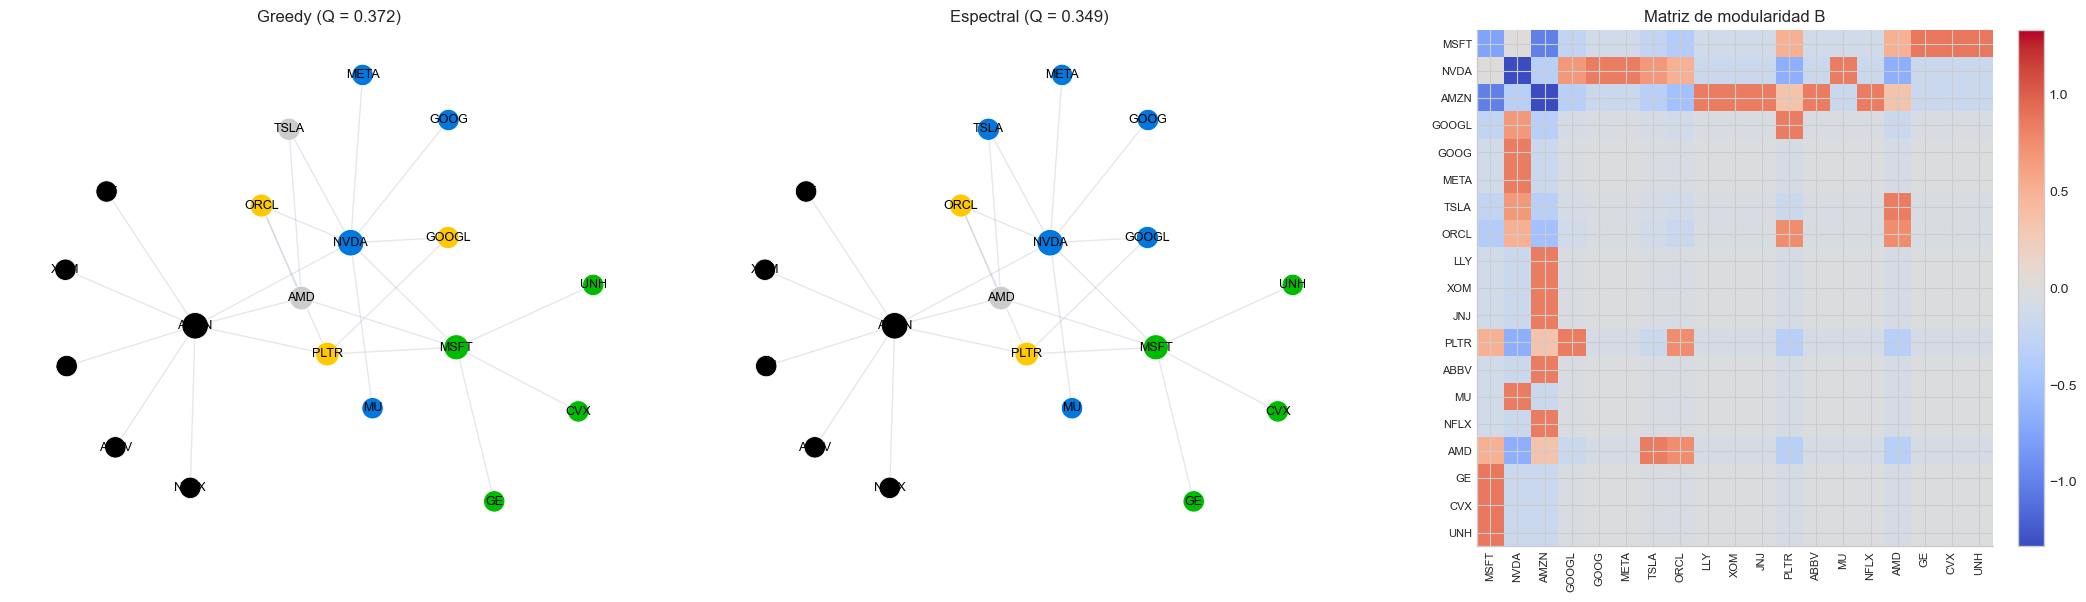

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

draw_partition(
    axes[0],
    G_real,
    comunidades_greedy,
    labels,
    title=f"Greedy (Q = {modularidad_greedy:.3f})",
    pos=pos_sp,
)
draw_partition(
    axes[1],
    G_real,
    comunidades_spectral,
    labels,
    title=f"Espectral (Q = {modularidad_spectral:.3f})",
    pos=pos_sp,
)
plot_modularity_heatmap(axes[2], B_df_sp, "Matriz de modularidad B")

plt.tight_layout()
plt.show()


**¿Qué cambia con la bisección espectral?**

La partición espectral llega también a **5 comunidades**, pero la modularidad baja a alrededor de **0.349**. La separación existe, pero es un poco menos limpia que la de `greedy`, igual que en el ejemplo de la otra notebook.


- El **primer eigenvector** separa el bloque `AMZN-ABBV-JNJ-LLY-NFLX-XOM` del resto. Ahí las entradas positivas del eigenvector principal se concentran en `AMZN` y sus vecinos más dependientes.
- Después, el método espectral distingue un bloque `MSFT-CVX-GE-UNH` y otro bloque tecnológico alrededor de `NVDA`.
- La diferencia respecto al inciso anterior es que `GOOGL` se va al bloque de `NVDA`, mientras que `PLTR` queda solo con `ORCL`.
- Para alcanzar las 5 comunidades, la última bisección termina **aislando a `AMD`**.

Los primeros cortes tienen eigenvalores ositivos y mejoran la modularidad acumulada; el último corte ya no es tan natural. En esta minired `greedy_modularity_communities` describe mejor los grupos locales, mientras que la matriz de modularidad resalta más la polarización global entre el frente de `AMZN` y el frente de cómputo corporativo.
